# Startup Taxi Fleet Optimization for Arkansas Regions Using Rideshare-Based Pricing

**Course:** DASC 32003 – Optimization Methods in Data Science

**Project Team:** Cody Uhl, Connor Anderson, Evan Muckleroy  

**Date:** April 17, 2026  

**Project Type:** Regional fleet design and profit optimization  

**Objective:** Determine the optimal taxi fleet composition across Arkansas regions using rideshare-based pricing benchmarks, cost modeling, and integer optimization.

# 1. Problem Definition and Motivation

This project studies how a startup taxi company in Arkansas should build its fleet across different regions.

The company uses rideshare prices as a competitive benchmark rather than setting prices independently. This creates a realistic optimization problem: the company must choose vehicles that maximize long-run profit while remaining cost-effective and operationally feasible.

The goal is to determine whether electric vehicles (EVs) or gasoline vehicles are more attractive under regional revenue differences, vehicle cost differences, and policy-style EV constraints.

# 2. Key Assumptions

To keep the problem tractable, we make the following assumptions:

1. Fleet decisions are solved independently for each Arkansas region.
2. The Boston Uber/Lyft dataset is used as a proxy for rideshare pricing behavior.
3. Taxi pricing is modeled as a fixed fraction of rideshare revenue.
4. Regional revenue differences are captured through Arkansas-specific scaling factors.
5. Operating costs scale approximately linearly with mileage.
6. EV charging limitations are represented through a downtime penalty.
7. Demand is assumed sufficient to fully utilize the chosen fleet.
8. Vehicle resale value is not included.

# 3. Mathematical Optimization Model

We solve the fleet optimization problem separately for each Arkansas region.

## Sets
- $(V_r$): set of feasible vehicle options for region $(r$)

## Parameters
- $(p_{v,r}$): 5-year profit contributed by one unit of vehicle $(v$) in region $(r$)
- $(c_v$): purchase price of vehicle $(v$)
- $(F_r$): required fleet size in region $(r$)
- $(B_r$): available vehicle-purchase budget in region $(r$)
- $(e_v $in {0,1}): indicator equal to 1 if vehicle $(v$) is an EV
- $(U_r^{EV}$): maximum allowed EV count in region $(r$)

## Decision Variable
- $(x_{v,r}$ in ${Z} {\ge 0}$): number of vehicles of type $(v$) assigned to region $(r$)

## Objective
$$
\max \sum_{v \in V_r} p_{v,r} x_{v,r}
$$

## Constraints

Fleet size:
$$
\sum_{v \in V_r} x_{v,r} = F_r
$$

Budget:
$$
\sum_{v \in V_r} c_v x_{v,r} \le B_r
$$

EV cap:
$$
\sum_{v \in V_r} e_v x_{v,r} \le U_r^{EV}
$$

Nonnegativity/integrality:
$$
x_{v,r} \in \mathbb{Z}_{\ge 0}
$$

## Interpretation

This integer optimization model determines how many vehicles of each type to allocate within a region in order to maximize total 5-year fleet profit while satisfying fleet size, budget, and EV-adoption constraints.

# 4. Data Sources and Parameter Mapping

We use three main data components:

1. **Boston rideshare data** to estimate benchmark pricing and revenue behavior.
2. **Arkansas regional scaling assumptions** to adjust benchmark revenue by region.
3. **Vehicle data** to estimate purchase cost, fuel cost, maintenance, insurance, and total cost of ownership.

These components are merged to construct the profit parameter used in the optimization model.

In [ ]:
# @title
# =========================
# 1. IMPORT LIBRARIES
# =========================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip -q install pyomo
!apt-get -qq install -y glpk-utils

import pyomo.environ as pyo

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

Selecting previously unselected package libsuitesparseconfig5:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../libsuitesparseconfig5_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libamd2:amd64.
Preparing to unpack .../libamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libcolamd2:amd64.
Preparing to unpack .../libcolamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libcolamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libglpk40:amd64.
Preparing to unpack .../libglpk40_5.0-1_amd64.deb ...
Unpacking libglpk40:amd64 (5.0-1) ...
Selecting previously unselected package glpk-utils.
Preparing to unpack .../glpk-utils_5.0-1_amd64.deb ...
Unpacking glpk-utils (5.0-1) ...
Setting up libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4b

In [ ]:
# @title
# =========================
# 2. MOUNT GOOGLE DRIVE
# =========================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# @title
# =========================
# 3. DEFINE FILE PATHS
# =========================

project_path = "/content/drive/MyDrive/Colab_Notebooks/EV_Gas_Optimization_Project"
data_path = os.path.join(project_path, "Data")
output_path = os.path.join(project_path, "Outputs")

os.makedirs(output_path, exist_ok=True)

boston_file = os.path.join(data_path, "boston_rideshare.csv")
vehicle_file = os.path.join(data_path, "clean_vehicle_dataset_for_optimization.csv")
regions_file = os.path.join(data_path, "Arkansas_Regions.csv")

In [ ]:
# @title
# =========================
# 4. SAFE CSV LOADER
# =========================

def load_csv_safely(file_path, encodings=("utf-8", "latin1", "cp1252")):
    """
    Load a CSV using several possible encodings.
    """
    for enc in encodings:
        try:
            df = pd.read_csv(file_path, encoding=enc)
            #print(f"Loaded {os.path.basename(file_path)} with encoding={enc}")
            return df
        except Exception:
            continue
    raise ValueError(f"Could not load file: {file_path}")

In [ ]:
# @title
# =========================
# 5. LOAD DATASETS
# =========================

boston = load_csv_safely(boston_file)
vehicles = load_csv_safely(vehicle_file)
regions = load_csv_safely(regions_file)

In [ ]:
# @title
# =========================
# 6. CLEAN COLUMN NAMES
# =========================

def clean_columns(df):
    """
    Standardize dataframe column names.
    """
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    return df

boston = clean_columns(boston)
vehicles = clean_columns(vehicles)
regions = clean_columns(regions)

In [ ]:
# @title
# =========================
# 7. STANDARDIZE VEHICLE / REGION COLUMNS
# =========================

vehicle_rename_map = {
    "model_year": "year",
    "make_name": "make",
    "model_name": "model",
    "msrp_usd": "msrp",
    "fuel_cost_per_mi": "fuel_cost_per_mile",
    "maintenance_cost_per_mi": "maintenance_per_mile",
    "annual_insurance_cost": "insurance_per_year",
    "ev_flag": "is_ev"
}
vehicles = vehicles.rename(columns={k: v for k, v in vehicle_rename_map.items() if k in vehicles.columns})

region_rename_map = {
    "ev_downtime_pct": "ev_downtime",
    "region_scale_factor": "scale_factor"
}
regions = regions.rename(columns={k: v for k, v in region_rename_map.items() if k in regions.columns})

required_vehicle_cols = [
    "make", "model", "year", "is_ev", "msrp",
    "fuel_cost_per_mile", "maintenance_per_mile", "insurance_per_year"
]
required_region_cols = ["region", "scale_factor", "ev_downtime", "miles_per_day"]

missing_vehicle_cols = [c for c in required_vehicle_cols if c not in vehicles.columns]
missing_region_cols = [c for c in required_region_cols if c not in regions.columns]

# 5. Revenue Model from the Boston Dataset

We first estimate benchmark rideshare revenue using the Boston Uber/Lyft dataset. This provides an external pricing reference that is later scaled to Arkansas regions and adjusted into a startup taxi pricing model.

In [ ]:
# @title
# =========================
# 8. CLEAN BOSTON DATA AND BUILD REVENUE MODEL
# =========================

# Keep only trips with valid fare and distance
boston = boston.dropna(subset=["price", "distance"]).copy()
boston = boston[(boston["price"] > 0) & (boston["distance"] > 0)]

# Revenue per mile for each trip
boston["revenue_per_mile"] = boston["price"] / boston["distance"]

# Summary statistics
avg_fare = boston["price"].mean()
avg_distance = boston["distance"].mean()
avg_revenue_per_mile = boston["revenue_per_mile"].mean()

print(f"Average fare: ${avg_fare:.2f}")
print(f"Average trip distance: {avg_distance:.2f} miles")
print(f"Average revenue per mile: ${avg_revenue_per_mile:.4f}")

Average fare: $16.55
Average trip distance: 2.19 miles
Average revenue per mile: $9.6877


In [ ]:
# @title
# =========================
# 9. BOSTON DRIVER DAILY ASSUMPTIONS
# =========================

assumed_trips_per_day_boston = 20
working_days_per_year = 300
years = 5

daily_revenue_boston = assumed_trips_per_day_boston * avg_fare
daily_miles_boston = assumed_trips_per_day_boston * avg_distance

print(f"Assumed trips per day in Boston: {assumed_trips_per_day_boston}")
print(f"Estimated daily revenue in Boston: ${daily_revenue_boston:.2f}")
print(f"Estimated daily miles in Boston: {daily_miles_boston:.2f}")

Assumed trips per day in Boston: 20
Estimated daily revenue in Boston: $330.90
Estimated daily miles in Boston: 43.79


# 6. Arkansas Regional Scaling

We scale the benchmark revenue model to Arkansas regions using regional demand multipliers and EV downtime assumptions. This allows the same pricing framework to reflect differences in operating conditions across Arkansas.

In [ ]:
# @title
# =========================
# 10. SCALE REVENUE TO ARKANSAS REGIONS
# =========================

regions = regions.copy()

regions["daily_revenue_gas"] = daily_revenue_boston * regions["scale_factor"]
regions["daily_revenue_ev"] = regions["daily_revenue_gas"] * (1 - regions["ev_downtime"])

regions["miles_5yr"] = regions["miles_per_day"] * working_days_per_year * years
regions["revenue_5yr_gas"] = regions["daily_revenue_gas"] * working_days_per_year * years
regions["revenue_5yr_ev"] = regions["daily_revenue_ev"] * working_days_per_year * years

# 7. Vehicle Cost and Profit Construction

Next, we combine each vehicle with each Arkansas region and compute:

- total cost of ownership (TCO)
- 5-year revenue
- 5-year profit
- return on investment (ROI)

This step converts the raw data into vehicle-region profit estimates that can be used in the optimization model.

In [ ]:
# @title
# =========================
# 11. CLEAN VEHICLE DATA
# =========================

vehicles = vehicles.copy()
vehicles = vehicles.dropna(subset=[c for c in required_vehicle_cols if c in vehicles.columns])
vehicles = vehicles[vehicles["msrp"] > 0]
vehicles = vehicles[vehicles["fuel_cost_per_mile"] >= 0]
vehicles = vehicles[vehicles["maintenance_per_mile"] >= 0]
vehicles = vehicles[vehicles["insurance_per_year"] >= 0]
vehicles["is_ev"] = vehicles["is_ev"].astype(int)

print("Vehicle rows after cleaning:", len(vehicles))

Vehicle rows after cleaning: 1077


In [ ]:
# @title
# =========================
# 12. CREATE VEHICLE-REGION COMBINATIONS
# =========================

vehicle_region = vehicles.assign(key=1).merge(regions.assign(key=1), on="key").drop(columns="key")
print("Vehicle-region rows:", len(vehicle_region))

Vehicle-region rows: 5385


In [ ]:
# @title
# =========================
# 13. COMPUTE TCO, PROFIT, AND ROI
# =========================

vehicle_region["fuel_cost_5yr_region"] = vehicle_region["fuel_cost_per_mile"] * vehicle_region["miles_5yr"]
vehicle_region["maintenance_cost_5yr_region"] = vehicle_region["maintenance_per_mile"] * vehicle_region["miles_5yr"]
vehicle_region["insurance_cost_5yr_region"] = vehicle_region["insurance_per_year"] * years

vehicle_region["tco_5yr_region"] = (
    vehicle_region["msrp"]
    + vehicle_region["fuel_cost_5yr_region"]
    + vehicle_region["maintenance_cost_5yr_region"]
    + vehicle_region["insurance_cost_5yr_region"]
)

vehicle_region["revenue_5yr"] = np.where(
    vehicle_region["is_ev"] == 1,
    vehicle_region["revenue_5yr_ev"],
    vehicle_region["revenue_5yr_gas"]
)

vehicle_region["profit_5yr"] = vehicle_region["revenue_5yr"] - vehicle_region["tco_5yr_region"]
vehicle_region["roi"] = vehicle_region["profit_5yr"] / vehicle_region["msrp"]


In [ ]:
# @title
# =========================
# 14. ADD REGION FEASIBILITY FLAGS
# =========================

if "ev_feasible" not in regions.columns:
    regions["ev_feasible"] = (regions["ev_downtime"] <= 0.10).astype(int)

if "gas_feasible" not in regions.columns:
    regions["gas_feasible"] = 1

vehicle_region = vehicle_region.drop(
    columns=[c for c in ["ev_feasible", "gas_feasible"] if c in vehicle_region.columns],
    errors="ignore"
)

vehicle_region = vehicle_region.merge(
    regions[["region", "ev_feasible", "gas_feasible"]],
    on="region",
    how="left"
)

In [ ]:
# @title
# =========================
# 15. SPLIT EV AND GAS CANDIDATES
# =========================

ev_candidates = vehicle_region[
    (vehicle_region["is_ev"] == 1) &
    (vehicle_region["ev_feasible"] == 1)
].copy()

gas_candidates = vehicle_region[
    (vehicle_region["is_ev"] == 0) &
    (vehicle_region["gas_feasible"] == 1)
].copy()


# 8. Baseline Vehicle Screening

Before solving the full fleet optimization model, we compare the strongest individual EV and gasoline vehicle in each region.

This screening step helps identify whether one technology appears more attractive under the current assumptions before moving to the full multi-vehicle fleet model.

In [ ]:
# @title
# =========================
# 16. BEST SINGLE VEHICLE BY REGION (RANKING)
# =========================

# Select best EV per region from feasible EV candidates
best_ev = (
    ev_candidates
    .sort_values(["region", "roi"], ascending=[True, False])
    .groupby("region")
    .first()
    .reset_index()
)

# Select best Gas per region from feasible gas candidates
best_gas = (
    gas_candidates
    .sort_values(["region", "roi"], ascending=[True, False])
    .groupby("region")
    .first()
    .reset_index()
)

# Merge results
compare_best_single = best_ev.merge(
    best_gas,
    on="region",
    suffixes=("_ev", "_gas")
)

# Determine which is better
compare_best_single["better_technology"] = np.where(
    compare_best_single["roi_ev"] > compare_best_single["roi_gas"],
    "EV",
    "Gas"
)

display(compare_best_single[[
    "region",
    "make_ev", "model_ev", "roi_ev",
    "make_gas", "model_gas", "roi_gas",
    "better_technology"
]].round(3))

,region,make_ev,model_ev,roi_ev,make_gas,model_gas,roi_gas,better_technology
0,Central Arkansas,Chevrolet,Spark EV,21.218,Nissan,Versa,23.730,Gas
1,Northeast Arkansas,Chevrolet,Spark EV,10.521,Nissan,Versa,12.422,Gas
2,Northwest Arkansas,Chevrolet,Spark EV,18.345,Nissan,Versa,20.550,Gas
3,River Valley,Chevrolet,Spark EV,11.906,Nissan,Versa,14.012,Gas


### Interpretation

The baseline screening suggests that gasoline vehicles outperform EVs in each Arkansas region under the current assumptions. In regions where EVs are feasible, the strongest gasoline candidate still has higher ROI than the strongest EV candidate.

# 9. Visual Analysis

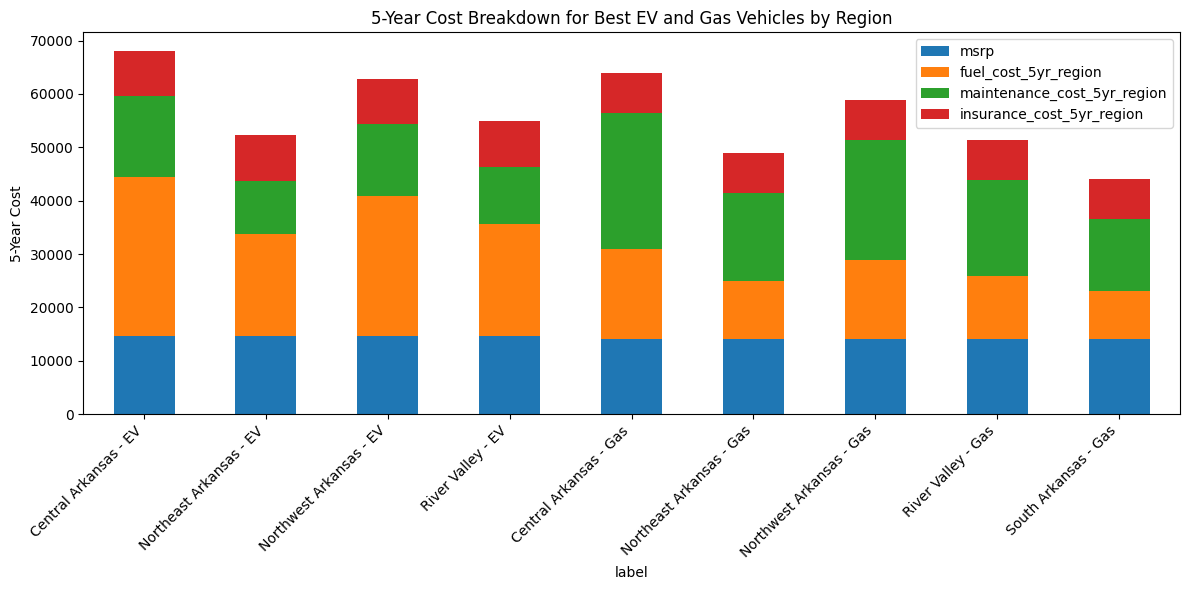

In [ ]:
# @title
# =========================
# 17. COST BREAKDOWN FOR BEST SINGLE VEHICLES
# Show figure only in final notebook if preferred.
# =========================

best_ev_plot = best_ev[["region", "fuel_cost_5yr_region", "maintenance_cost_5yr_region", "insurance_cost_5yr_region", "msrp"]].copy()
best_gas_plot = best_gas[["region", "fuel_cost_5yr_region", "maintenance_cost_5yr_region", "insurance_cost_5yr_region", "msrp"]].copy()

best_ev_plot["technology"] = "EV"
best_gas_plot["technology"] = "Gas"

cost_plot = pd.concat([best_ev_plot, best_gas_plot], ignore_index=True)
cost_plot["label"] = cost_plot["region"] + " - " + cost_plot["technology"]
cost_plot = cost_plot.set_index("label")[["msrp", "fuel_cost_5yr_region", "maintenance_cost_5yr_region", "insurance_cost_5yr_region"]]

cost_plot.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.ylabel("5-Year Cost")
plt.title("5-Year Cost Breakdown for Best EV and Gas Vehicles by Region")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

The cost breakdown shows that EVs benefit from lower operating costs, but this advantage is not currently large enough to offset their higher upfront cost and other modeled constraints under the Arkansas assumptions.

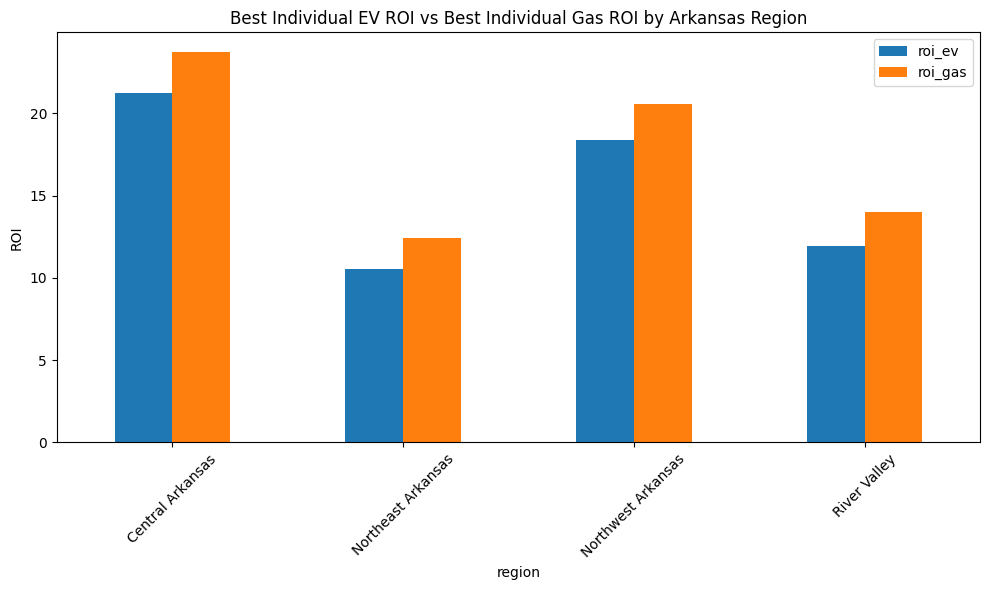

In [ ]:
# @title
# =========================
# 18. PLOT BEST SINGLE ROI COMPARISON
# Show figure.
# =========================

plot_df_single = compare_best_single[
    ["region", "roi_ev", "roi_gas"]
].set_index("region")

plot_df_single.plot(kind="bar", figsize=(10, 6))
plt.ylabel("ROI")
plt.title("Best Individual EV ROI vs Best Individual Gas ROI by Arkansas Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 10. Time-Based ROI Analysis Under Benchmark Revenue

In [ ]:
# @title
# =========================
# 19. TIME-BASED ROI MODEL
# Hide code if desired.
# =========================

years_list = [1, 2, 3, 4, 5]

for y in years_list:
    vehicle_region[f"miles_{y}yr"] = vehicle_region["miles_per_day"] * working_days_per_year * y
    vehicle_region[f"revenue_{y}yr"] = vehicle_region["revenue_5yr"] * (y / 5)

    vehicle_region[f"fuel_cost_{y}yr"] = vehicle_region["fuel_cost_per_mile"] * vehicle_region[f"miles_{y}yr"]
    vehicle_region[f"maintenance_cost_{y}yr"] = vehicle_region["maintenance_per_mile"] * vehicle_region[f"miles_{y}yr"]
    vehicle_region[f"insurance_cost_{y}yr"] = vehicle_region["insurance_per_year"] * y

    vehicle_region[f"tco_{y}yr"] = (
        vehicle_region["msrp"]
        + vehicle_region[f"fuel_cost_{y}yr"]
        + vehicle_region[f"maintenance_cost_{y}yr"]
        + vehicle_region[f"insurance_cost_{y}yr"]
    )

    vehicle_region[f"profit_{y}yr"] = vehicle_region[f"revenue_{y}yr"] - vehicle_region[f"tco_{y}yr"]
    vehicle_region[f"roi_{y}yr"] = vehicle_region[f"profit_{y}yr"] / vehicle_region["msrp"]


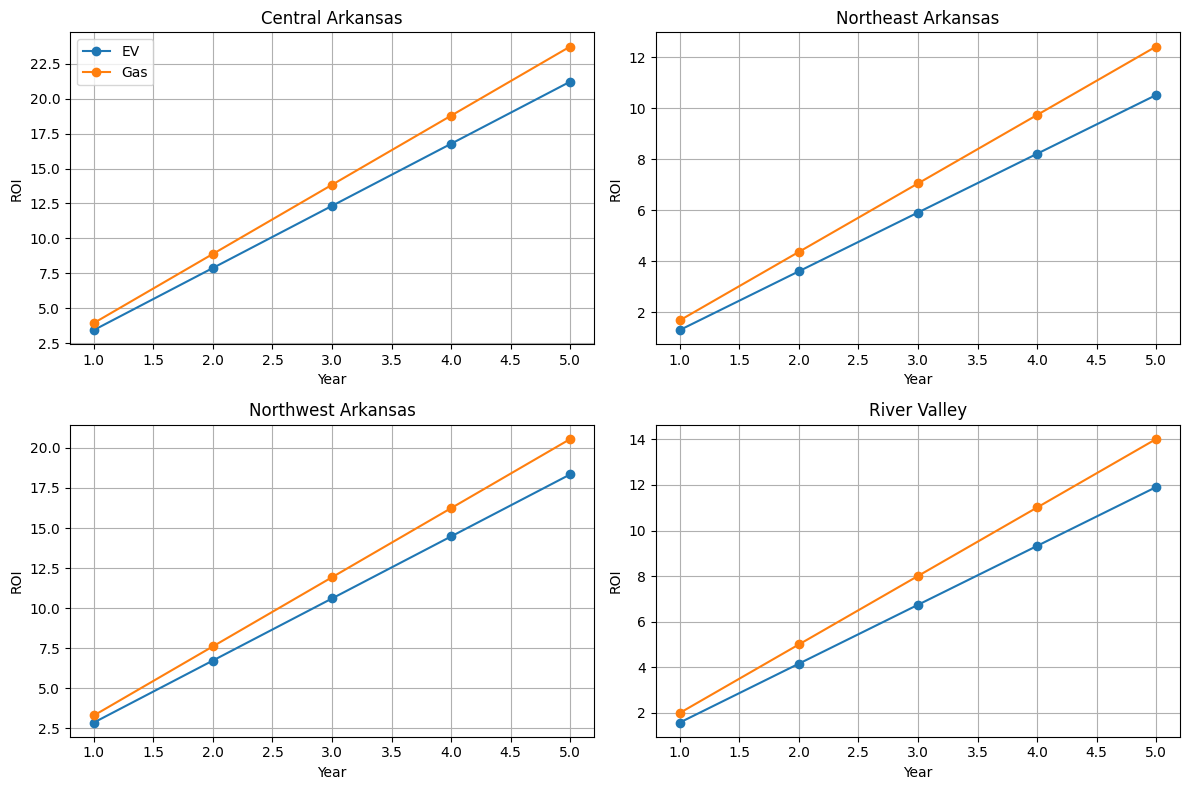

In [ ]:
# @title
# =========================
# 20. ROI OVER TIME BY REGION
# Show figure.
# =========================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

regions_to_plot = [r for r in compare_best_single["region"].unique() if r in best_ev["region"].values][:4]

for ax, region_name in zip(axes, regions_to_plot):
    ev_row = vehicle_region[
        (vehicle_region["region"] == region_name) &
        (vehicle_region["make"] == best_ev.loc[best_ev["region"] == region_name, "make"].values[0]) &
        (vehicle_region["model"] == best_ev.loc[best_ev["region"] == region_name, "model"].values[0]) &
        (vehicle_region["year"] == best_ev.loc[best_ev["region"] == region_name, "year"].values[0])
    ].iloc[0]

    gas_row = vehicle_region[
        (vehicle_region["region"] == region_name) &
        (vehicle_region["make"] == best_gas.loc[best_gas["region"] == region_name, "make"].values[0]) &
        (vehicle_region["model"] == best_gas.loc[best_gas["region"] == region_name, "model"].values[0]) &
        (vehicle_region["year"] == best_gas.loc[best_gas["region"] == region_name, "year"].values[0])
    ].iloc[0]

    ev_roi = [ev_row[f"roi_{y}yr"] for y in years_list]
    gas_roi = [gas_row[f"roi_{y}yr"] for y in years_list]

    ax.plot(years_list, ev_roi, marker="o", label="EV")
    ax.plot(years_list, gas_roi, marker="o", label="Gas")
    ax.set_title(region_name)
    ax.set_xlabel("Year")
    ax.set_ylabel("ROI")
    ax.grid()

axes[0].legend()
plt.tight_layout()
plt.show()

### Interpretation

This figure illustrates four representative Arkansas regions to show whether the technology preference remains stable over time.

# 11. Sensitivity Analysis

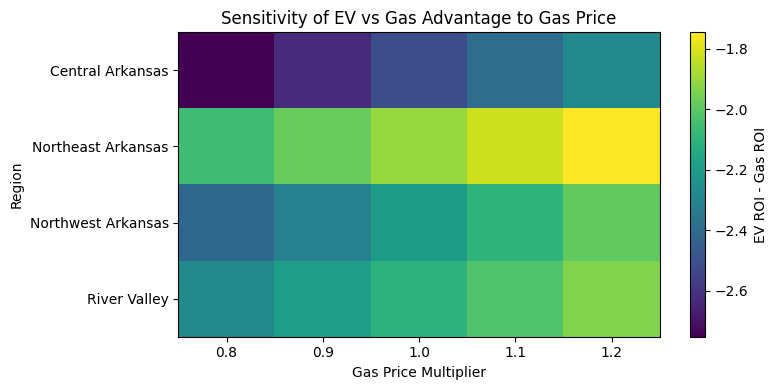

In [ ]:
# @title
# =========================
# 21. GAS PRICE SENSITIVITY HEATMAP
# Show figure.
# =========================

gas_multipliers = [0.8, 0.9, 1.0, 1.1, 1.2]
heatmap_results = []

for mult in gas_multipliers:
    temp = vehicle_region.copy()

    temp.loc[temp["is_ev"] == 0, "fuel_cost_adj"] = temp["fuel_cost_per_mile"] * mult
    temp.loc[temp["is_ev"] == 1, "fuel_cost_adj"] = temp["fuel_cost_per_mile"]

    temp["fuel_cost_5yr_adj"] = temp["fuel_cost_adj"] * temp["miles_5yr"]

    temp["tco_adj"] = (
        temp["msrp"]
        + temp["fuel_cost_5yr_adj"]
        + temp["maintenance_cost_5yr_region"]
        + temp["insurance_cost_5yr_region"]
    )

    temp["profit_adj"] = temp["revenue_5yr"] - temp["tco_adj"]
    temp["roi_adj"] = temp["profit_adj"] / temp["msrp"]

    best_ev_sens = temp[(temp["is_ev"] == 1) & (temp["ev_feasible"] == 1)] \
      .groupby("region")["roi_adj"].max().reset_index(name="best_ev_roi")

    best_gas_sens = temp[(temp["is_ev"] == 0) & (temp["gas_feasible"] == 1)] \
      .groupby("region")["roi_adj"].max().reset_index(name="best_gas_roi")

    merged = best_ev_sens.merge(best_gas_sens, on="region")
    merged["roi_diff"] = merged["best_ev_roi"] - merged["best_gas_roi"]
    merged["gas_multiplier"] = mult

    heatmap_results.append(merged)

heatmap_df = pd.concat(heatmap_results, ignore_index=True)
heatmap_pivot = heatmap_df.pivot(index="region", columns="gas_multiplier", values="roi_diff")

plt.figure(figsize=(8, 4))
plt.imshow(heatmap_pivot, aspect="auto")
plt.xticks(range(len(heatmap_pivot.columns)), heatmap_pivot.columns)
plt.yticks(range(len(heatmap_pivot.index)), heatmap_pivot.index)
plt.colorbar(label="EV ROI - Gas ROI")
plt.title("Sensitivity of EV vs Gas Advantage to Gas Price")
plt.xlabel("Gas Price Multiplier")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

### Interpretation

Sensitivity analysis helps determine whether the recommendation is robust. If EVs become competitive only under large gas-price increases, then the base-case preference for gasoline vehicles is relatively stable.

# 12. Competitive Taxi Pricing Model

Instead of treating rideshare revenue as the final business outcome, we model a startup taxi company that prices its service competitively relative to rideshare platforms.

We assume taxi revenue is a fixed fraction of rideshare revenue, which creates a more realistic pricing basis for the final fleet optimization model.

In [ ]:
# @title
# =========================
# 22. COMPETITIVE TAXI PRICING
# =========================

taxi_price_factor = 0.95  # 95% of rideshare price

# Create taxi revenue columns in regions
regions["taxi_revenue_5yr_gas"] = regions["revenue_5yr_gas"] * taxi_price_factor
regions["taxi_revenue_5yr_ev"] = regions["revenue_5yr_ev"] * taxi_price_factor

# Merge them into vehicle_region
vehicle_region = vehicle_region.drop(
    columns=[c for c in ["taxi_revenue_5yr_gas", "taxi_revenue_5yr_ev"] if c in vehicle_region.columns],
    errors="ignore"
)

vehicle_region = vehicle_region.merge(
    regions[["region", "taxi_revenue_5yr_gas", "taxi_revenue_5yr_ev"]],
    on="region",
    how="left"
)

# Compute taxi revenue and profit
vehicle_region["revenue_5yr_taxi"] = np.where(
    vehicle_region["is_ev"] == 1,
    vehicle_region["taxi_revenue_5yr_ev"],
    vehicle_region["taxi_revenue_5yr_gas"]
)

vehicle_region["profit_5yr_taxi"] = (
    vehicle_region["revenue_5yr_taxi"] - vehicle_region["tco_5yr_region"]
)

vehicle_region["roi_5yr_taxi"] = (
    vehicle_region["profit_5yr_taxi"] / vehicle_region["msrp"]
)

vehicle_region[[
    "region", "make", "model", "is_ev",
    "revenue_5yr_taxi", "profit_5yr_taxi", "roi_5yr_taxi"
]].head()

,region,make,model,is_ev,revenue_5yr_taxi,profit_5yr_taxi,roi_5yr_taxi
0,Northwest Arkansas,Nissan,GT-R,0,330075.253538,156624.059206,1.378612
1,Central Arkansas,Nissan,GT-R,0,377228.861186,196798.840943,1.732232
2,River Valley,Nissan,GT-R,0,235768.038241,72785.082776,0.640657
3,Northeast Arkansas,Nissan,GT-R,0,212191.234417,52697.691907,0.463847
4,South Arkansas,Nissan,GT-R,0,141460.822945,-11053.893654,-0.097297


# 13. Final Fleet Optimization Model

We now solve the main optimization problem for each Arkansas region.

The model determines how many vehicles of each type to include in the fleet in order to maximize total 5-year taxi profit subject to:
- fleet size requirements
- purchase budget limits
- EV adoption limits

In [ ]:
# =========================
# 23. TAXI FLEET OPTIMIZATION MODEL
# =========================

def solve_taxi_fleet(df_region, fleet_size=20, budget=None,
                     ev_cap=None, force_ev_cap=False,
                     min_ev=0, min_gas=0):
    df_region = df_region.reset_index(drop=True).copy()

    model = pyo.ConcreteModel()
    model.I = pyo.RangeSet(0, len(df_region) - 1)
    model.x = pyo.Var(model.I, within=pyo.NonNegativeIntegers)

    model.obj = pyo.Objective(
        expr=sum(df_region.loc[i, "profit_5yr_taxi"] * model.x[i] for i in model.I),
        sense=pyo.maximize
    )

    model.fleet_size = pyo.Constraint(
        expr=sum(model.x[i] for i in model.I) == fleet_size
    )

    if budget is not None:
        model.budget = pyo.Constraint(
            expr=sum(df_region.loc[i, "msrp"] * model.x[i] for i in model.I) <= budget
        )

    ev_expr = sum(df_region.loc[i, "is_ev"] * model.x[i] for i in model.I)
    gas_expr = sum((1 - df_region.loc[i, "is_ev"]) * model.x[i] for i in model.I)

    if ev_cap is not None:
        if force_ev_cap:
            model.ev_cap = pyo.Constraint(expr=ev_expr == ev_cap)
        else:
            model.ev_cap = pyo.Constraint(expr=ev_expr <= ev_cap)

    model.min_ev = pyo.Constraint(expr=ev_expr >= min_ev)
    model.min_gas = pyo.Constraint(expr=gas_expr >= min_gas)

    solver = pyo.SolverFactory("glpk")
    results = solver.solve(model, tee=False)

    status = results.solver.status
    term = results.solver.termination_condition

    if status != pyo.SolverStatus.ok or term not in [
        pyo.TerminationCondition.optimal,
        pyo.TerminationCondition.feasible
    ]:
        raise ValueError(f"Optimization failed: status={status}, termination={term}")

    df_region["allocation"] = [
        int(round(pyo.value(model.x[i]))) for i in model.I
    ]

    return df_region[df_region["allocation"] > 0]

In [ ]:
# @title
# =========================
# 24. RUN FLEET MODEL
# =========================

fleet_results = {}

for region_name in vehicle_region["region"].unique():
    sub = vehicle_region[
        (vehicle_region["region"] == region_name) &
        (
            ((vehicle_region["is_ev"] == 1) & (vehicle_region["ev_feasible"] == 1)) |
            ((vehicle_region["is_ev"] == 0) & (vehicle_region["gas_feasible"] == 1))
        )
    ].copy()

    fleet_results[region_name] = solve_taxi_fleet(
        sub,
        fleet_size=20,
        budget=600000,
        ev_cap=5,
        force_ev_cap=False,
        min_ev=0,
        min_gas=0
    )

,region,total_profit,total_purchase_cost,EV_count,Gas_count
0,Northwest Arkansas,5422916.04,280800.0,0,20
1,Central Arkansas,6266282.99,280800.0,0,20
2,River Valley,3686329.54,280800.0,0,20
3,Northeast Arkansas,3264646.07,280800.0,0,20
4,South Arkansas,1949743.04,280800.0,0,20


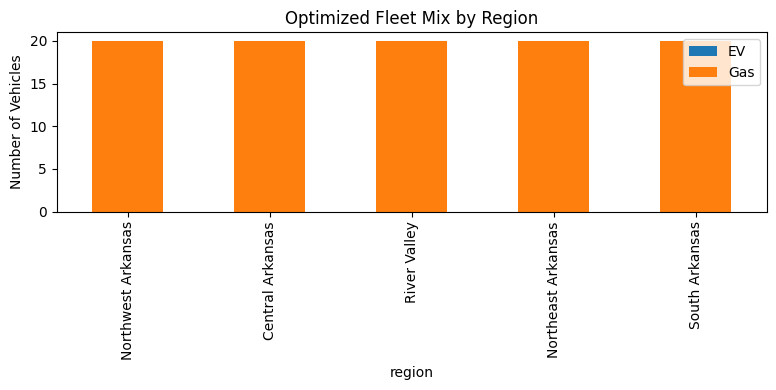

In [ ]:
# @title
# =========================
# 25. FLEET MIX BY REGION
# =========================

fleet_mix = []
summary_rows = []

for r, df in fleet_results.items():
    ev = df[df["is_ev"] == 1]["allocation"].sum()
    gas = df[df["is_ev"] == 0]["allocation"].sum()
    total_profit = (df["allocation"] * df["profit_5yr_taxi"]).sum()
    total_cost = (df["allocation"] * df["msrp"]).sum()

    fleet_mix.append({
        "region": r,
        "EV": ev,
        "Gas": gas
    })

    summary_rows.append({
        "region": r,
        "total_profit": total_profit,
        "total_purchase_cost": total_cost,
        "EV_count": ev,
        "Gas_count": gas
    })

fleet_summary_df = pd.DataFrame(summary_rows)
display(fleet_summary_df.round(2))

fleet_mix_df = pd.DataFrame(fleet_mix).set_index("region")

fleet_mix_df.plot(kind="bar", stacked=True, figsize=(8,4))
plt.title("Optimized Fleet Mix by Region")
plt.ylabel("Number of Vehicles")
plt.tight_layout()
plt.show()

In [ ]:
# @title
# =========================
# 26. COMPARE FLEET STRATEGIES
# =========================

comparison_rows = []

for region_name in vehicle_region["region"].unique():
    sub = vehicle_region[
        (vehicle_region["region"] == region_name) &
        (
            ((vehicle_region["is_ev"] == 1) & (vehicle_region["ev_feasible"] == 1)) |
            ((vehicle_region["is_ev"] == 0) & (vehicle_region["gas_feasible"] == 1))
        )
    ].copy()

    if sub.empty:
        continue

    fleet_size = 20
    budget = 600000
    ev_cap = 5

    # Optimized fleet
    opt_df = solve_taxi_fleet(
        sub,
        fleet_size=fleet_size,
        budget=budget,
        ev_cap=ev_cap,
        force_ev_cap=False,
        min_ev=0,
        min_gas=0
    )
    optimized_profit = (opt_df["allocation"] * opt_df["profit_5yr_taxi"]).sum()

    # All-gas fleet
    gas_df = solve_taxi_fleet(
        sub,
        fleet_size=fleet_size,
        budget=budget,
        ev_cap=0,
        force_ev_cap=False,
        min_ev=0,
        min_gas=fleet_size
    )
    all_gas_profit = (gas_df["allocation"] * gas_df["profit_5yr_taxi"]).sum()

    # Hybrid fleet: at least 1 EV and at least 1 gas
    try:
        hybrid_df = solve_taxi_fleet(
            sub,
            fleet_size=fleet_size,
            budget=budget,
            ev_cap=ev_cap,
            force_ev_cap=False,
            min_ev=1,
            min_gas=1
        )
        hybrid_profit = (hybrid_df["allocation"] * hybrid_df["profit_5yr_taxi"]).sum()
    except Exception:
        hybrid_profit = np.nan

    # All-EV fleet
    try:
        ev_df = solve_taxi_fleet(
            sub,
            fleet_size=fleet_size,
            budget=budget,
            ev_cap=fleet_size,
            force_ev_cap=False,
            min_ev=fleet_size,
            min_gas=0
        )
        all_ev_profit = (ev_df["allocation"] * ev_df["profit_5yr_taxi"]).sum()
    except Exception:
        all_ev_profit = np.nan

    comparison_rows.append({
        "region": region_name,
        "optimized_profit": optimized_profit,
        "all_gas_profit": all_gas_profit,
        "hybrid_profit": hybrid_profit,
        "all_ev_profit": all_ev_profit
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df["opt_vs_gas_%"] = (
    (comparison_df["optimized_profit"] - comparison_df["all_gas_profit"])
    / comparison_df["all_gas_profit"]
) * 100

comparison_df["opt_vs_hybrid_%"] = np.where(
    comparison_df["hybrid_profit"].notna(),
    ((comparison_df["optimized_profit"] - comparison_df["hybrid_profit"])
     / comparison_df["hybrid_profit"]) * 100,
    np.nan
)

comparison_df["opt_vs_ev_%"] = np.where(
    comparison_df["all_ev_profit"].notna(),
    ((comparison_df["optimized_profit"] - comparison_df["all_ev_profit"])
     / comparison_df["all_ev_profit"]) * 100,
    np.nan
)

display(comparison_df.round(2))

,region,optimized_profit,all_gas_profit,hybrid_profit,all_ev_profit,opt_vs_gas_%,opt_vs_hybrid_%,opt_vs_ev_%
0,Northwest Arkansas,5422916.04,5422916.04,5402504.90,5014693.24,0.0,0.38,8.14
1,Central Arkansas,6266282.99,6266282.99,6243213.09,5804884.85,0.0,0.37,7.95
2,River Valley,3686329.54,3686329.54,3664036.70,3240472.64,0.0,0.61,13.76
3,Northeast Arkansas,3264646.07,3264646.07,3244398.03,2859685.22,0.0,0.62,14.16
4,South Arkansas,1949743.04,1949743.04,NaN,NaN,0.0,NaN,NaN


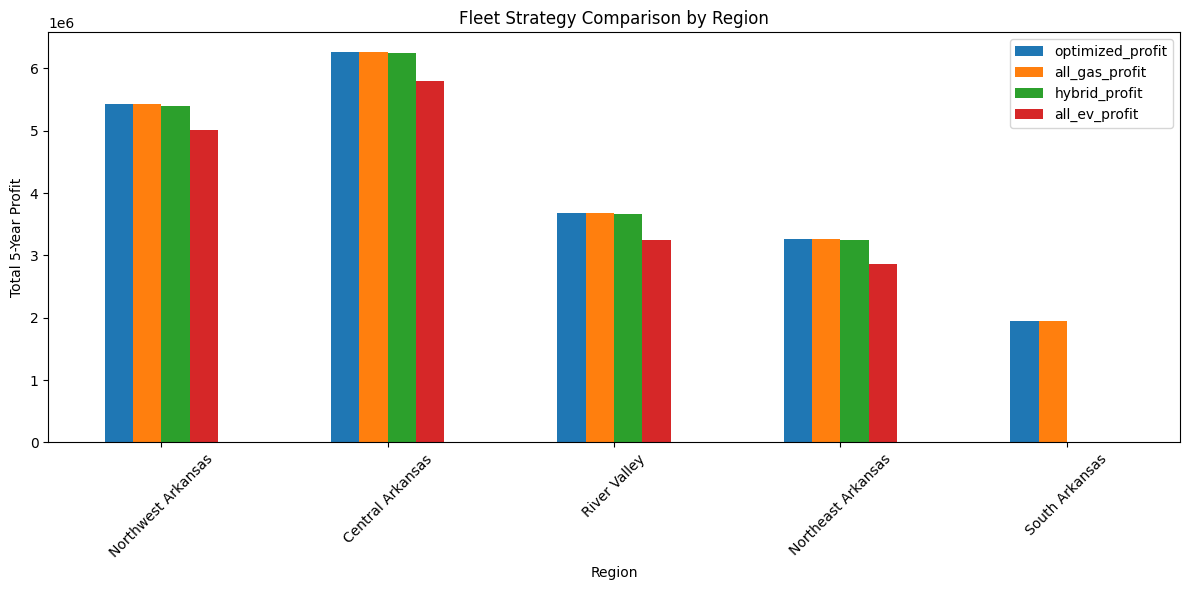

In [ ]:
# @title
# =========================
# 27. FLEET STRATEGY COMPARISON GRAPH
# =========================

plot_df = comparison_df.set_index("region")[
    ["optimized_profit", "all_gas_profit", "hybrid_profit", "all_ev_profit"]
]

plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Fleet Strategy Comparison by Region")
plt.ylabel("Total 5-Year Profit")
plt.xlabel("Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

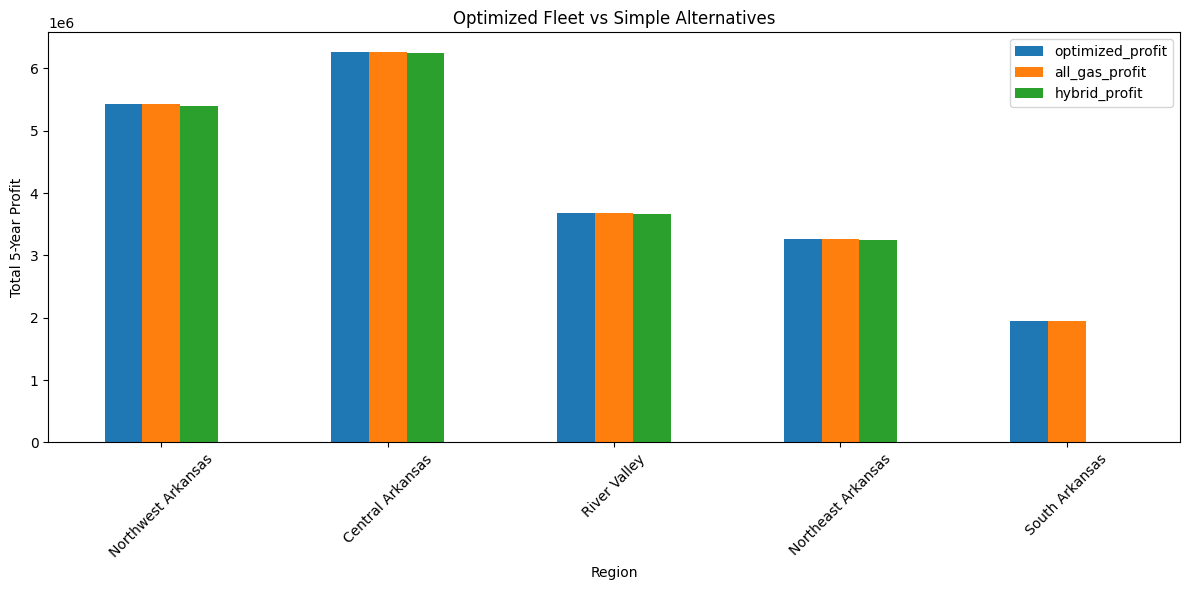

In [ ]:
# @title
# =========================
# 28. PRESENTATION VERSION: SIMPLIFIED COMPARISON GRAPH
# =========================

plot_df_simple = comparison_df.set_index("region")[
    ["optimized_profit", "all_gas_profit", "hybrid_profit"]
]

plot_df_simple.plot(kind="bar", figsize=(12, 6))
plt.title("Optimized Fleet vs Simple Alternatives")
plt.ylabel("Total 5-Year Profit")
plt.xlabel("Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 14. Discussion

The optimization results show a strong preference for gasoline vehicles across most Arkansas regions under the current assumptions.

This outcome is driven by three main factors:

1. EVs have higher upfront purchase costs.
2. EV downtime reduces effective revenue generation.
3. Revenue differences between EVs and gasoline vehicles are not large enough to offset the cost gap.

Because revenue is primarily differentiated by region and fuel type rather than detailed vehicle-specific service characteristics, the model tends to favor lower-cost vehicles when cost differences dominate.

The comparison against all-gas, all-EV, and hybrid fleet strategies shows that the optimization model provides a more structured and flexible decision framework than simple fleet construction rules. Even when the optimized fleet resembles an all-gas solution, the model still adds value by formally incorporating budget, fleet size, and EV-cap constraints across regions.

The gas-price sensitivity analysis also suggests that the base-case recommendation is relatively robust. EVs become more competitive only under sufficiently large increases in gasoline costs or under improved operating assumptions.

In practice, a startup taxi company may not choose a fleet based purely on profit maximization. A business may also value vehicle variety, such as including SUVs or larger-capacity vehicles to serve premium or group-trip markets similar to UberXL-style offerings. While this may reduce total profit relative to the purely optimized fleet, it may improve customer experience, service flexibility, and long-term competitiveness.

Overall, the results suggest that under the modeled Arkansas conditions, cost efficiency dominates fuel-efficiency advantages when constructing a startup taxi fleet. However, broader strategic business goals could justify selecting a more varied fleet than the strictly profit-maximizing solution.


# 15. Limitations

This project has several limitations:

- The Boston dataset is used as a proxy for Arkansas rideshare pricing behavior.
- Arkansas regional demand is represented through scaling assumptions rather than observed trip-level demand.
- EV charging feasibility is simplified using a downtime penalty rather than detailed infrastructure modeling.
- Taxi pricing is treated as a fixed percentage of rideshare pricing rather than optimized endogenously.
- Revenue varies mainly by region and fuel type, not strongly by individual vehicle characteristics.
- The model does not explicitly reward vehicle variety, premium service tiers, or customer preference for larger vehicles such as SUVs.

Even with these limitations, the model still provides a useful framework for comparing fleet strategies and understanding the conditions under which EV adoption may become more attractive. It also provides a foundation for future extensions involving differentiated service types, richer demand modeling, and endogenous pricing decisions.


# 16. Key Takeaways

1. Under the current assumptions, gasoline vehicles are more profitable than EVs for Arkansas taxi fleets.
2. Vehicle purchase cost and operational constraints outweigh EV fuel savings in the base case.
3. Integer optimization provides a practical framework for regional fleet planning under budget and EV-cap constraints.
4. The optimized fleet performs better than simple all-gas, all-EV, or hybrid benchmark strategies while remaining flexible to policy-style constraints.
5. A real business may still choose a more varied fleet mix to support customer choice, premium services, and long-term market strategy.

In [ ]:
# @title
# =========================
# 29. SAVE OUTPUT FILES
# Hide this cell after it runs successfully.
# =========================

vehicle_region.to_csv(os.path.join(output_path, "vehicle_region_full_results.csv"), index=False)
fleet_summary_df.to_csv(os.path.join(output_path, "fleet_summary_by_region.csv"), index=False)

print("Core outputs saved to:", output_path)

Core outputs saved to: /content/drive/MyDrive/Colab_Notebooks/EV_Gas_Optimization_Project/Outputs
